# First Detect object Using YOLO

In [25]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt
from utils.yolo import *
from utils.video import *
from utils.color import *
from utils.ROI import * 
import os
import json
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

#show_results('data/oneFramewithWand.png', confidence_threshold=0.0)
# json_path = "data/annotations_group_11.json"

# # Split fixed video using load_json
# video_split(json_path, fixed=True, output_dir="output/splits_fixed")

# # Split dynamic video using load_json
# video_split(json_path, fixed=False, output_dir="splits_dynamic")

In [122]:
frame = cv2.imread("data/oneFramewithWand.png")

masks, labels = detect_objects(frame)

#now we should detect the wand on the part without the object 

#first pop  the person mask 
#sheck before if the list are not empty !

to_remove = ["person", "dining table"]

# Keep only the masks and labels that are NOT in to_remove
filtered = [(m, l) for m, l in zip(masks, labels) if l not in to_remove]

# Unzip back into separate lists
if filtered:  # avoid error if filtered is empty
    masks, labels = zip(*filtered)
    masks, labels = list(masks), list(labels)
else:
    masks, labels = [], []

print(labels)
# Then we add all the masks 
m = np.zeros_like(masks[0])
for mask in masks:
    mask = (mask * 255).astype(np.uint8)  # ensure 0–255
    m = cv2.bitwise_or(m, mask)


#then we remove them from the original image
mask_inv = cv2.bitwise_not(m)
# Ensure mask has same shape as frame (3 channels)
if len(mask_inv.shape) == 2:
    mask_inv_color = cv2.cvtColor(mask_inv, cv2.COLOR_GRAY2BGR)
else:
    mask_inv_color = mask_inv


frame2 = cv2.bitwise_and(frame,frame, mask=mask_inv)

wand_mask =detect_color(frame2,[255,0,10],[50,50],[255,255], tuning = 25)

ok,wand= roi(wand_mask ,10 , 15)
red_roi = np.copy(wand) 
ok,red_roi= roi(red_roi ,10 , 100)

# now That we have and the object mask and the wand mask see if they overlap with each object one by one 

l = np.zeros(len(masks), dtype=bool)
for i, mask in enumerate(masks):
    # Ensure both masks are binary uint8
    overlap = cv2.bitwise_and(mask, red_roi)

    # Count number of overlapping pixels
    overlap_pixels = np.count_nonzero(overlap)
    # Mark as overlapping
    if overlap_pixels >= 50:
        l[i] = True 

# now we have the list of masks and a list indicating if we should apply the trick or not 

# now we should  apply function to the object if true 

st = np.where(l == True)[0]


obj = masks[st[0]]
#take the frame and obj and give the masked frame
obj = (obj * 255).astype(np.uint8)  # if your mask is 0/1

# Apply mask to image
masked_image = cv2.bitwise_and(frame, frame, mask=obj)

# on this masked image change the color 

obj_mask = detect_color(masked_image, [0,0,255] ,[100,100],[255,255], tuning=25)

#apply changing color 

proc_frame = change_color_mask(frame, [0,0,255] , [255,0,0],obj_mask)





0: 320x640 1 person, 1 sports ball, 1 orange, 1 dining table, 491.4ms
Speed: 16.1ms preprocess, 491.4ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 640)
['sports ball', 'orange']
the original color is : [0, 0, 255]
the target  color is : [255, 0, 0]
the color change worked successfully 


In [123]:
# np.shape(wand) ,ok
# cv2.cvtColor(frame2 ,cv2.COLOR_BGR2RGB)
masked_image = cv2.cvtColor(masked_image ,cv2.COLOR_BGR2RGB)
obj_mask = cv2.cvtColor(obj_mask ,cv2.COLOR_BGR2RGB)
proc_frame =cv2.cvtColor(proc_frame ,cv2.COLOR_BGR2RGB)

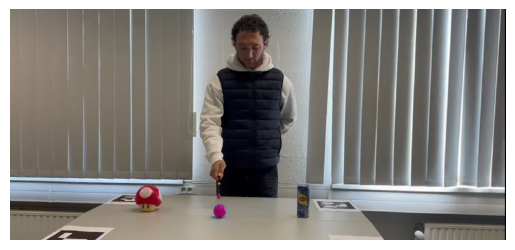

In [124]:
plt.imshow(proc_frame)
plt.axis('off')
plt.show()

In [ ]:
if not st :
    print("ok")
    

In [42]:
def detect_objects(frame):
    """
    Detect objects in an image using YOLOv8 and convert boxes to masks.
    
    Args:
        frame: BGR image (numpy array)
    
    Returns:
        masks: list of uint8 masks (1 inside box, 0 outside)
        labels: list of class names corresponding to each mask
    """
    # Load YOLO model
    model = YOLO('yolo11x.pt')  # Load the model

    # Convert image to RGB
    image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Perform detection
    results = model(image_rgb)[0]

    masks = []
    labels = []

    H, W = frame.shape[:2]
    class_names = results.names

    # Process detections
    boxes = results.boxes
    for box in boxes:
        # Box coordinates
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Create mask for this object
        mask = np.zeros((H, W), dtype=np.uint8)
        cv2.rectangle(mask, (x1, y1), (x2, y2), color=1, thickness=-1)
        masks.append(mask)

        # Get class label
        class_id = int(box.cls[0])
        class_name = class_names[class_id]
        labels.append(class_name)

    return masks, labels

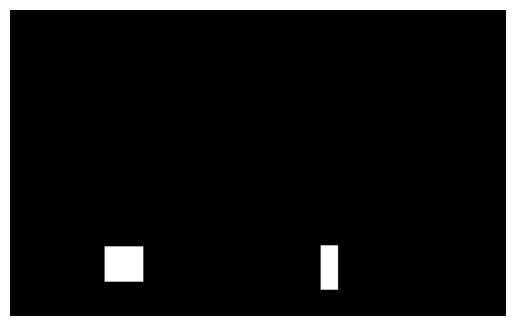

In [ ]:
# frame = cv2.imread("data/oneFramewithWand.png")

# def show_all_masks(masks):
#     n = len(masks)
#     plt.figure()
#     m = np.zeros_like(masks[0])
#     for  mask in masks:
#          m = cv2.add(mask,m)
#     plt.imshow(m, cmap='gray')
#     plt.axis('off')
#     plt.show()
# show_all_masks(masks)

In [147]:
def frame_processing(frame) : 
    #first detect object 
    masks, labels = detect_objects(frame)
    
    status_list = np.zeros(len(masks), dtype=bool)
    #remove undesired 
    to_remove = ["person", "dining table"]
    filtered = [(m, l) for m, l in zip(masks, labels) if l not in to_remove]

    # Unzip back into separate lists
    if filtered:  # avoid error if filtered is empty
        masks, labels = zip(*filtered)
        masks, labels = list(masks), list(labels)
    else:
        masks, labels = [], []
        return frame , status_list
    print(labels)
    
    # Then we add all the masks 
    m = np.zeros_like(masks[0])
    for mask in masks:
        mask = (mask * 255).astype(np.uint8)  # ensure 0–255
        m = cv2.bitwise_or(m, mask)
        
    #then we remove them from the original image
    mask_inv = cv2.bitwise_not(m)
    # Ensure mask has same shape as frame (3 channels)
    if len(mask_inv.shape) == 2:
        mask_inv_color = cv2.cvtColor(mask_inv, cv2.COLOR_GRAY2BGR)
    else:
        mask_inv_color = mask_inv
    
    frame_without_object = cv2.bitwise_and(frame,frame, mask=mask_inv)
    
    #detect the wand without the object 
    wand_mask =detect_color(frame_without_object,[255,0,10],[50,50],[255,255], tuning = 25)
    
    ok,wand= roi(wand_mask ,10 , 15)
    red_roi = np.copy(wand) 
    ok,red_roi= roi(red_roi ,10 , 100)
    
    # now That we have the object mask and the wand mask
    # see if they overlap with each other
    red_roi = (red_roi * 255).astype(np.uint8)
    for i, mask in enumerate(masks):
        # Ensure both masks are binary uint8
        mask = (mask * 255).astype(np.uint8)
        overlap = cv2.bitwise_and(mask, red_roi)

        # Count number of overlapping pixels
        overlap_pixels = np.count_nonzero(overlap)
        # Mark as overlapping
        if overlap_pixels >= 50:
            status_list[i] = True 
    
    # now we have the list of masks and a list indicating
    # if we should apply the trick or not 

    # now we should  apply function to the object if true 
    st = np.where(status_list == True)[0]

    if not (st.size > 0) : 
        return frame , status_list
    obj = masks[st[0]]
    #take the frame and obj and give the masked frame
    obj = (obj * 255).astype(np.uint8)  # if your mask is 0/1
    
    # Apply mask to image
    masked_image = cv2.bitwise_and(frame, frame, mask=obj)
    
    # on this masked image detect the color to be changed 
    
    obj_mask = detect_color(masked_image, [0,0,255] ,[100,100],[255,255], tuning=25)
    
    #apply changing color 
    
    proc_frame = change_color_mask(frame, [0,0,255] , [255,0,0],obj_mask)
    
    return proc_frame ,status_list



0: 320x640 1 person, 1 sports ball, 1 orange, 1 dining table, 630.9ms
Speed: 1.3ms preprocess, 630.9ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 640)
['sports ball', 'orange']
the original color is : [0, 0, 255]
the target  color is : [255, 0, 0]
the color change worked successfully 


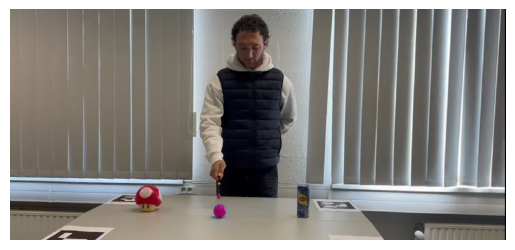

In [148]:
frame = cv2.imread("data/oneFramewithWand.png")
f,_ = frame_processing(frame)
f =cv2.cvtColor(f ,cv2.COLOR_BGR2RGB)
plt.imshow(f)
plt.axis('off')
plt.show()


In [144]:
in_path  = "data/splits_fixed/trick_2.mp4"       
out_path = "output/test.mp4"

apply_function_to_video(in_path,out_path , frame_processing)


0: 384x640 1 sports ball, 1 orange, 706.2ms
Speed: 20.0ms preprocess, 706.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
['sports ball', 'orange']

0: 384x640 1 sports ball, 1 orange, 641.7ms
Speed: 1.5ms preprocess, 641.7ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)
['sports ball', 'orange']

0: 384x640 1 sports ball, 1 orange, 636.9ms
Speed: 1.6ms preprocess, 636.9ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)
['sports ball', 'orange']

0: 384x640 1 sports ball, 1 orange, 666.2ms
Speed: 1.8ms preprocess, 666.2ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)
['sports ball', 'orange']

0: 384x640 1 sports ball, 1 orange, 621.9ms
Speed: 1.4ms preprocess, 621.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
['sports ball', 'orange']

0: 384x640 1 sports ball, 1 orange, 718.2ms
Speed: 1.5ms preprocess, 718.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
['sports ba

KeyboardInterrupt: 